# Modelos de Difusion con PyTorch

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana05_diffusion.ipynb)

En esta notebook vamos a construir una introduccion a los **modelos de difusión**.

Objetivos de aprendizaje:

- entender el proceso directo de agregar ruido paso a paso;
- entrenar una red que prediga el ruido usando PyTorch;
- implementar el muestreo inverso para generar nuevas muestras;
- conectar la intuicion del ejemplo 2D con DDPMs usados en imagenes.


## Librerias necesarias

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 70
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)
print("Torch:", torch.__version__)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


Dispositivo: cpu
Torch: 2.5.1


## Parte 1

### Un dataset simple para ver la geometría

En imágenes, los modelos de difusión operan en miles o millones de dimensiones. Para aprender la idea, eso complica demasiado la visualizacion.

Por eso usaremos un dataset 2D con forma de dos medias lunas, de paso comparamos con las notebooks de NFs. Si el modelo aprende bien, debería poder generar muestras con esa misma geometria.


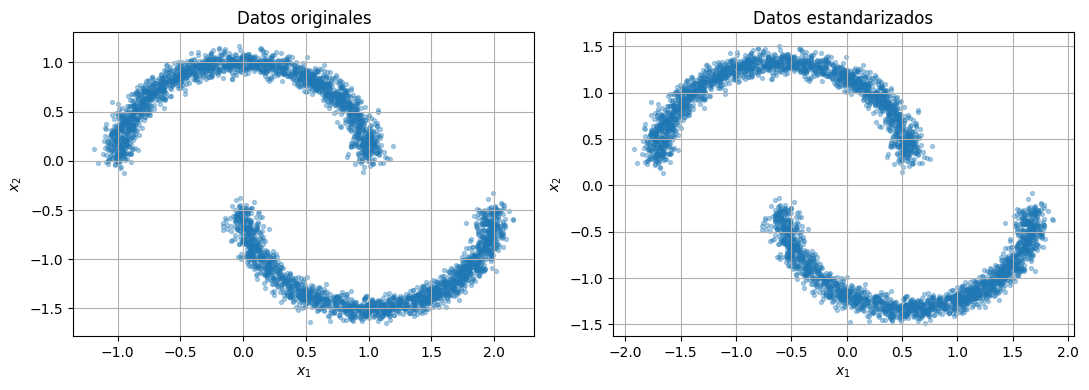

In [7]:
def sample_two_moons(n_samples=4000, noise=0.06, device=DEVICE):
    n1 = n_samples // 2
    n2 = n_samples - n1

    theta1 = torch.rand(n1, device=device) * math.pi
    theta2 = torch.rand(n2, device=device) * math.pi

    moon1 = torch.stack([torch.cos(theta1), torch.sin(theta1)], dim=1)
    moon2 = torch.stack([1.0 - torch.cos(theta2), -torch.sin(theta2) - 0.5], dim=1)

    x = torch.cat([moon1, moon2], dim=0)
    x = x + noise * torch.randn_like(x)

    perm = torch.randperm(x.size(0), device=device)
    return x[perm]


class Standardizer:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def encode(self, x):
        return (x - self.mean) / self.std

    def decode(self, x):
        return x * self.std + self.mean


def make_standardizer(x):
    mean = x.mean(0, keepdim=True)
    std = x.std(0, keepdim=True).clamp_min(1e-4)
    return Standardizer(mean=mean, std=std)


def scatter_2d(x, ax=None, title="", alpha=0.35, s=8, color="#1f77b4"):
    if ax is None:
        _, ax = plt.subplots()
    x = x.detach().cpu()
    ax.scatter(x[:, 0], x[:, 1], s=s, alpha=alpha, color=color)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    return ax


def compare_samples(reference, generated, title_left="Datos", title_right="Muestras"):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    scatter_2d(reference, ax=axes[0], title=title_left, color="#1f77b4")
    scatter_2d(generated, ax=axes[1], title=title_right, color="#d62728")
    plt.tight_layout()
    plt.show()


# Generamos y luego estandarizamos los datos.
# La estandarizacion no cambia la forma geometrica, pero facilita el entrenamiento
# porque deja las escalas de ambas coordenadas en rangos comparables.
raw_data = sample_two_moons()
standardizer = make_standardizer(raw_data)
train_data = standardizer.encode(raw_data)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
scatter_2d(raw_data, ax=axes[0], title="Datos originales")
scatter_2d(train_data, ax=axes[1], title="Datos estandarizados")
plt.tight_layout()
plt.show()


## Parte 2

### Proceso directo: destruir estructura agregando ruido

La primera mitad de un modelo de difusión es fácil de definir: tomamos un dato limpio $x_0$ y le agregamos ruido gaussiano en varios pasos.

En DDPM, el proceso directo se escribe como:

$$
q(x_t \mid x_{t-1}) = \mathcal N\left(x_t; \sqrt{1-\beta_t}\,x_{t-1},\, \beta_t I\right).
$$

Vimos que si componemos muchos pasos, tambien podemos muestrear directamente $x_t$ desde $x_0$:

$$
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad \varepsilon \sim \mathcal N(0, I),
$$

donde $\alpha_t = 1 - \beta_t$ y $\bar\alpha_t = \prod_{s=1}^t \alpha_s$.

Esto es importante porque durante el entrenamiento no hace falta simular todos los pasos intermedios: podemos saltar directo al tiempo $t$ deseado.


In [8]:
# T es la cantidad total de pasos de difusion.
# En problemas reales puede ser mucho mas grande, pero para una notebook corta
# conviene un valor que permita entrenar y muestrear rapido.
T = 150

# beta_t controla cuanto ruido agregamos en cada paso.
# Esta es una schedule lineal simple: al principio agregamos poco ruido y luego mas.
betas = torch.linspace(1e-4, 0.02, T, device=DEVICE)
alphas = 1.0 - betas

# alpha_bar_t = prod_{s<=t} alpha_s resume el efecto acumulado de todos los pasos
# del proceso directo. Esta cantidad aparece todo el tiempo en las formulas.
alpha_bars = torch.cumprod(alphas, dim=0)

# alpha_bars_prev guarda alpha_bar_{t-1}. Lo usamos en la varianza posterior del paso inverso.
# Para t=0 definimos alpha_bar_{-1} = 1 de manera convencional.
alpha_bars_prev = torch.cat([torch.ones(1, device=DEVICE), alpha_bars[:-1]], dim=0)

# Guardamos varias combinaciones frecuentes para no recalcularlas dentro del entrenamiento
# y del muestreo. Esto vuelve el codigo mas legible y tambien un poco mas eficiente.
sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.rsqrt(alphas)
posterior_variance = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)


def extract(coefficients, t, x_shape):
    # coefficients tiene un valor por cada tiempo t.
    # gather(0, t) elige, para cada elemento del batch, el coeficiente correspondiente
    # a su paso temporal. Por eso t debe ser un tensor de enteros de forma [batch].
    out = coefficients.gather(0, t)

    # Luego reshapeamos a [batch, 1, ..., 1] para que PyTorch pueda hacer broadcasting
    # al multiplicarlo por tensores como x0 o noise sin tener que copiar datos.
    return out.view(-1, *([1] * (len(x_shape) - 1)))


def q_sample(x0, t, noise=None):
    # Esta funcion implementa el atajo cerrado:
    # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps
    # Es clave porque evita simular todos los pasos intermedios uno por uno.
    if noise is None:
        noise = torch.randn_like(x0)
    return (
        extract(sqrt_alpha_bars, t, x0.shape) * x0
        + extract(sqrt_one_minus_alpha_bars, t, x0.shape) * noise
    )


print(f"Cantidad de pasos: {T}")
print(f"beta_0 = {betas[0].item():.6f}")
print(f"beta_T = {betas[-1].item():.6f}")


Cantidad de pasos: 150
beta_0 = 0.000100
beta_T = 0.020000


torch.Size([4000, 2])
torch.Size([4000, 2])
torch.Size([4000, 2])
torch.Size([4000, 2])


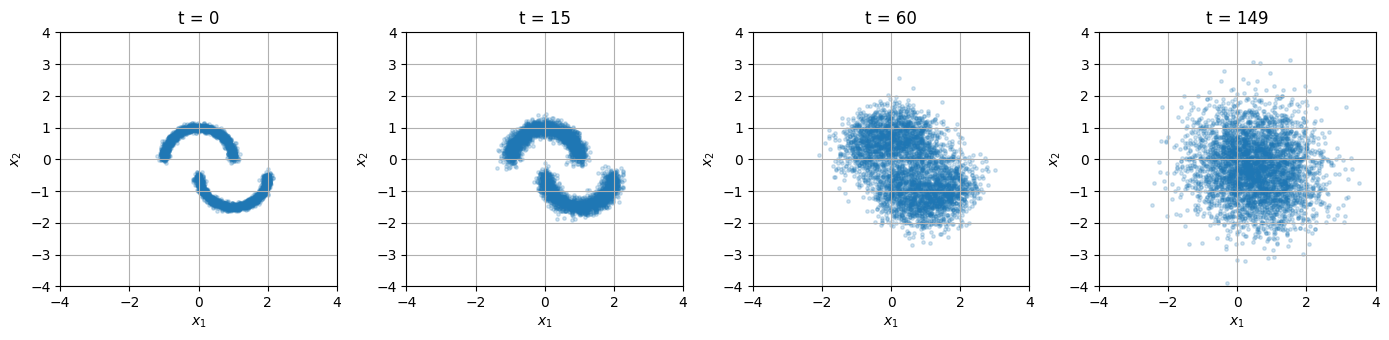

In [ ]:
times_to_show = [0, 15, 60, 149]
fig, axes = plt.subplots(1, len(times_to_show), figsize=(14, 3.5))

for ax, step in zip(axes, times_to_show):
    # Aca usamos el mismo t para todo el dataset porque queremos visualizar
    # como se ve la distribucion completa en distintos tiempos fijos.
    t = torch.full((train_data.size(0),), step, device=DEVICE, dtype=torch.long)
    noisy = q_sample(train_data, t)
    scatter_2d(standardizer.decode(noisy).cpu(), ax=ax, title=f"t = {step}", alpha=0.20, s=6)
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)

plt.tight_layout()
plt.show()


A medida que $t$ crece, la estructura de las medias lunas se pierde y la nube de puntos se parece cada vez mas a una gaussiana isotrópica.

La tarea del modelo será aprender la operación inversa: dado un punto ruidoso $x_t$ y el tiempo $t$, estimar qué parte de ese punto corresponde al ruido agregado.


## Parte 3

### Que aprende la red

Una forma popular de entrenar un modelo de difusion es pedirle que prediga el ruido $\varepsilon$ usado para construir $x_t$.

La red recibe como entrada el par $(x_t, t)$ y devuelve una aproximacion $\varepsilon_\theta(x_t, t)$.

La perdida mas usada en la presentacion introductoria es:

$$
\mathcal L = \mathbb E_{x_0, t, \varepsilon}\left[\left\|\varepsilon - \varepsilon_\theta(x_t, t)\right\|_2^2\right].
$$

En palabras: mostramos ejemplos ruidosos y entrenamos a la red para que reconstruya el ruido que se agrego.

En un modelo de difusión hace falta un **sinusoidal time embedding** porque la red no solo debe ver la muestra ruidosa $x_t$, sino también saber en qué paso temporal $t$ se encuentra, ya que el nivel de ruido y la tarea de denoising cambian a lo largo del proceso. En lugar de usar $t$ como un simple número, se lo transforma en un vector sinusoidal que representa mejor la posición temporal y permite que la red capture relaciones suaves entre pasos cercanos, aprendiendo así de manera más efectiva cómo quitar ruido según el instante del proceso.

In [15]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, max_period=10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, t):
        # La mitad de las componentes seran senos y la otra mitad cosenos.
        half_dim = self.dim // 2

        # Repartimos las frecuencias en escala logaritmica: algunas componentes
        # cambian rapido con t y otras mucho mas lento. Eso le da a la red
        # informacion temporal a varias escalas.
        scale = math.log(self.max_period) / max(half_dim - 1, 1)
        freqs = torch.exp(-scale * torch.arange(half_dim, device=t.device, dtype=torch.float32))

        # t tiene forma [batch]. Con unsqueeze(1) pasa a [batch, 1] y al multiplicar
        # por freqs[None, :] obtenemos una matriz [batch, half_dim]. Cada fila es
        # el embedding temporal de un elemento del batch.
        angles = (t.float().unsqueeze(1) / max(T - 1, 1)) * freqs.unsqueeze(0) * 1000.0
        emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

        # Si dim es impar, completamos con un cero para mantener exactamente
        # la dimension pedida.
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class NoisePredictor(nn.Module):
    def __init__(self, data_dim=2, time_dim=64, hidden_dim=128):
        super().__init__()
        self.time_embedding = SinusoidalTimeEmbedding(time_dim)
        self.net = nn.Sequential(
            nn.Linear(data_dim + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def forward(self, x, t):
        # La red no solo ve x_t: tambien necesita saber en que paso temporal esta.
        # Por eso concatenamos el embedding temporal al dato ruidoso.
        time_features = self.time_embedding(t)
        return self.net(torch.cat([x, time_features], dim=1))


def train_diffusion(model, data, epochs=350, batch_size=256, lr=2e-3, verbose_every=50):
    model = model.to(DEVICE)
    data = data.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(data.size(0), device=data.device)
        total = 0.0

        for i in range(0, data.size(0), batch_size):
            idx = perm[i : i + batch_size]
            batch = data[idx]

            # Cada elemento del batch recibe un tiempo t aleatorio distinto.
            # Asi, en promedio, la red aprende a quitar ruido en todos los niveles
            # del proceso de difusion.
            t = torch.randint(0, T, (batch.size(0),), device=batch.device)

            # Generamos el ruido objetivo y construimos x_t directamente con q_sample.
            # La red tratara de recuperar este mismo noise a partir de (x_t, t).
            noise = torch.randn_like(batch)
            noisy_batch = q_sample(batch, t, noise)

            predicted_noise = model(noisy_batch, t)

            # La perdida mas simple de DDPM es un MSE entre el ruido real y el predicho.
            # Aunque parece una eleccion ad hoc, esta forma esta muy conectada con
            # score matching y con la derivacion teorica del modelo.
            loss = F.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item() * batch.size(0)

        mean_loss = total / data.size(0)
        history.append(mean_loss)
        if epoch % verbose_every == 0 or epoch == 1:
            print(f"epoch={epoch:4d}  mse_ruido={mean_loss:.5f}")

    return history


model = NoisePredictor()
history = train_diffusion(model, train_data, epochs=600)


epoch=   1  mse_ruido=0.89193
epoch=  50  mse_ruido=0.53475
epoch= 100  mse_ruido=0.49705
epoch= 150  mse_ruido=0.51264
epoch= 200  mse_ruido=0.47682
epoch= 250  mse_ruido=0.49023
epoch= 300  mse_ruido=0.47474
epoch= 350  mse_ruido=0.49234
epoch= 400  mse_ruido=0.47377
epoch= 450  mse_ruido=0.47890
epoch= 500  mse_ruido=0.47705
epoch= 550  mse_ruido=0.49437
epoch= 600  mse_ruido=0.48112


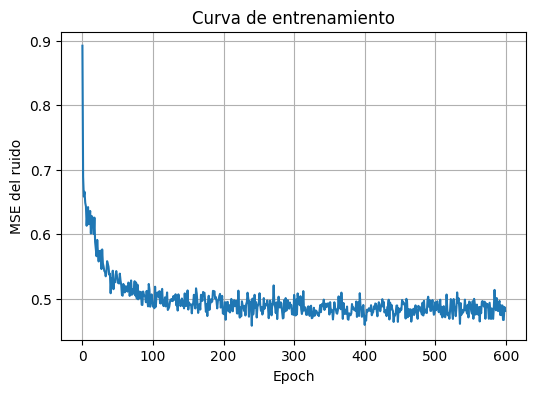

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(history)
plt.title("Curva de entrenamiento")
plt.xlabel("Epoch")
plt.ylabel("MSE del ruido")
plt.show()


## Parte 4

### Muestreo inverso

Una vez entrenada la red, partimos desde ruido puro $x_T \sim \mathcal N(0, I)$ y vamos deshaciendo el proceso paso a paso.

En DDPM, una forma estandar de escribir la media del paso inverso es:

$$
\mu_\theta(x_t, t) = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t, t)\right).
$$

Luego se agrega una pequeña cantidad de ruido gaussiano controlada por la varianza posterior, excepto en el ultimo paso.

Si el predictor de ruido es bueno, la cadena empieza en una nube gaussiana y termina en una distribucion que se parece a los datos reales.


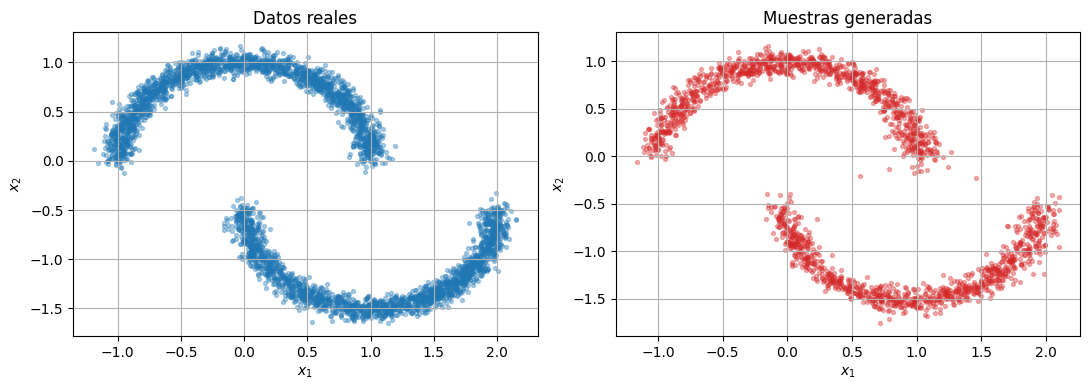

In [17]:
@torch.no_grad()
def sample_ddpm(model, n_samples, capture_steps=None):
    # En muestreo no necesitamos gradientes: solo aplicamos la cadena inversa.
    model.eval()

    # El proceso inverso arranca desde ruido gaussiano puro x_T.
    x = torch.randn(n_samples, 2, device=DEVICE)
    snapshots = [(T, x.detach().cpu())]
    capture_steps = set([] if capture_steps is None else capture_steps)

    for step in reversed(range(T)):
        # Recorremos los tiempos al reves: T-1, T-2, ..., 0.
        t = torch.full((n_samples,), step, device=DEVICE, dtype=torch.long)
        eps_theta = model(x, t)

        beta_t = extract(betas, t, x.shape)
        sqrt_one_minus_ab_t = extract(sqrt_one_minus_alpha_bars, t, x.shape)
        sqrt_recip_alpha_t = extract(sqrt_recip_alphas, t, x.shape)

        # Esta es la media del paso inverso p_theta(x_{t-1} | x_t).
        # La formula surge de reemplazar el ruido desconocido por la prediccion
        # de la red dentro de la expresion cerrada del posterior gaussiano.
        model_mean = sqrt_recip_alpha_t * (x - (beta_t / sqrt_one_minus_ab_t) * eps_theta)

        if step > 0:
            # Mientras no lleguemos al ultimo paso, agregamos una pequena parte aleatoria.
            # Eso mantiene el caracter estocastico del muestreo DDPM.
            variance_t = extract(posterior_variance.clamp_min(1e-20), t, x.shape)
            x = model_mean + torch.sqrt(variance_t) * torch.randn_like(x)
        else:
            # En t=0 ya no agregamos mas ruido: la muestra final queda dada solo por la media.
            x = model_mean

        if step in capture_steps:
            snapshots.append((step, x.detach().cpu()))

    return x, snapshots


# Guardamos algunos estados intermedios para poder visualizar como una nube de ruido
# se va deformando hasta parecerse a la distribucion de datos.
capture_steps = [110, 70, 30, 0]
generated, snapshots = sample_ddpm(model, n_samples=2000, capture_steps=capture_steps)
generated_decoded = standardizer.decode(generated.cpu())

compare_samples(raw_data.cpu(), generated_decoded, title_left="Datos reales", title_right="Muestras generadas")


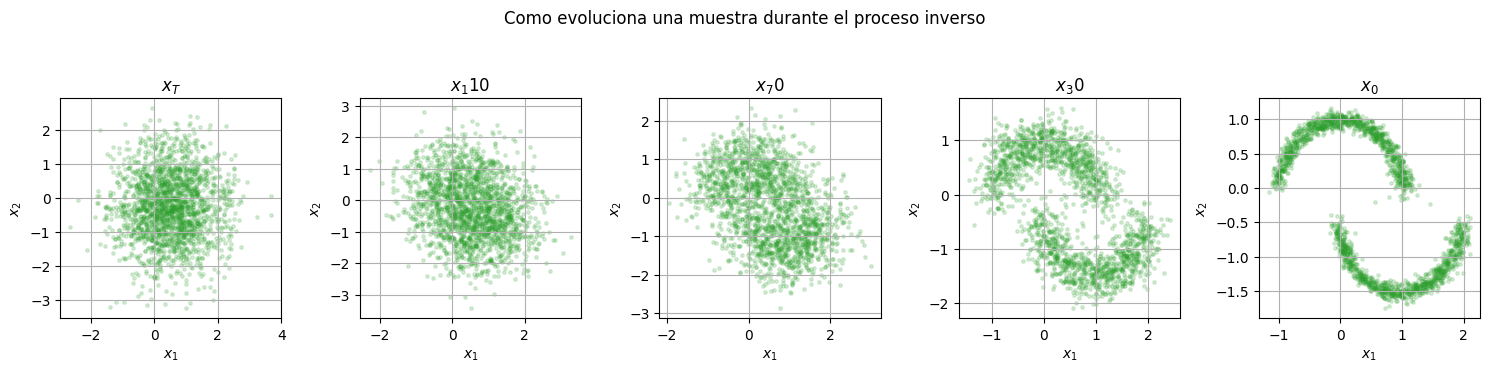

In [18]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(15, 3.5))

for ax, (step, sample) in zip(axes, snapshots):
    title = "$x_T$" if step == T else f"$x_{step}$"
    scatter_2d(standardizer.decode(sample), ax=ax, title=title, alpha=0.18, s=6, color="#2ca02c")

plt.suptitle("Como evoluciona una muestra durante el proceso inverso", y=1.05)
plt.tight_layout()
plt.show()


El modelo no memoriza puntos individuales. Lo que aprende es un campo de correcciones: para cada punto ruidoso y para cada nivel de ruido, estima hacia donde conviene moverse para recuperar estructura.

En el ejemplo 2D esto se ve como una nube gaussiana que se deforma gradualmente hasta tomar la forma de los datos.

En imagenes, exactamente la misma idea se aplica sobre tensores de pixeles o sobre latentes comprimidos. Lo que cambia es la arquitectura de la red y el costo computacional, no la logica basica del entrenamiento.
